# 01 – Data Acquisition: Hourly Temperature Observations (2012)

## Objective

This notebook retrieves raw hourly temperature observations for Oklahoma (starting with Oklahoma City) for the year 2012.

We will collect raw observational data from:

- NOAA surface observation stations
- Oklahoma Mesonet stations
- Potential additional observational networks

The goal of this notebook is **not analysis**.  
The goal is to:

1. Retrieve reproducible raw data
2. Preserve it in original form
3. Store it in the `data/raw/` directory
4. Document metadata and station details

This notebook establishes the foundation for the entire Weather Agreement Lab.

Downstream notebooks will:
- Clean and align this data
- Measure agreement between agencies
- Build a machine learning-based fusion model

# Environment Setup (Run Before Executing This Notebook)

This notebook is part of the **Weather Agreement Lab**.
Before running the code, please create a Python virtual environment and install the required dependencies.

---

# 1. Clone the Repository

```bash
git clone git@github.com:jeremy-evert/handson-ml3.git
cd handson-ml3/Weather_Agreement_Lab
```

---

# 2. Create a Virtual Environment

Linux / macOS

```bash
python3 -m venv .venv
```

Windows

```powershell
python -m venv .venv
```

---

# 3. Activate the Virtual Environment

Linux / macOS

```bash
source .venv/bin/activate
```

Windows

```powershell
.venv\Scripts\activate
```

---

# 4. Install the Required Packages

```bash
pip install --upgrade pip
pip install -r requirements_weather_lab.txt
```

---

# 5. Register the Jupyter Kernel

This allows the notebook to use your virtual environment.

```bash
python -m ipykernel install --user \
  --name weather_lab_env \
  --display-name "Python (Weather Lab)"
```

---

# 6. Open the Notebook in VS Code

```bash
code .
```

Then:

1. Open the notebook file (`01_data_pull.ipynb`)
2. Click **Select Kernel** in the upper right
3. Choose **Python (Weather Lab)**

---

# Alternative: Run as a Web Notebook

You can also launch Jupyter directly:

```bash
jupyter notebook
```

Then open:

```
01_data_pull.ipynb
```

---

# Requirements

Dependencies are listed in:

```
requirements_weather_lab.txt
```

These include:

* pandas
* numpy
* matplotlib
* scikit-learn
* jupyter / ipykernel
* requests

---

# Project Structure

```
Weather_Agreement_Lab
│
├── 01_data_pull.ipynb
├── 02_alignment_and_cleaning.ipynb
├── 03_forecast_uncertainty.ipynb
├── 04_agreement_metrics.ipynb
├── 05_data_fusion.ipynb
│
├── requirements_weather_lab.txt
└── README.md
```

Notebook flow:

1️⃣ **Data Acquisition**
2️⃣ **Cleaning & Alignment**
3️⃣ **Forecast Uncertainty**
4️⃣ **Agreement Metrics**
5️⃣ **Data Fusion**

---

## Tip

If something fails, verify your kernel is using:

```
Python (Weather Lab)
```

and that the virtual environment is activated.

---

If you'd like, I can also show you a **very slick trick** that a lot of ML researchers use:

You can make the notebook **auto-detect if it is inside a venv and warn the student if it isn't**.

It takes about **6 lines of Python** and saves hours of confused debugging from students. 🧠💡


In [2]:
# If running inside a fresh environment, uncomment:
# !pip install requests pandas python-dotenv

import os
import requests
import pandas as pd
from datetime import datetime

In [3]:
import sys
import os
import platform
import subprocess
from datetime import datetime
import pkg_resources

print("===== SESSION DIAGNOSTICS =====\n")

print("Timestamp:", datetime.now())
print("\n--- Python ---")
print("Python version:", sys.version)
print("Python executable:", sys.executable)

print("\n--- Virtual Environment ---")
print("VIRTUAL_ENV:", os.environ.get("VIRTUAL_ENV"))

print("\n--- Working Directory ---")
print("Current working directory:", os.getcwd())

print("\n--- Platform ---")
print("System:", platform.system())
print("Release:", platform.release())
print("Machine:", platform.machine())
print("Processor:", platform.processor())

print("\n--- Installed Key Packages ---")
for pkg in ["pandas", "requests", "python-dotenv"]:
    try:
        version = pkg_resources.get_distribution(pkg).version
        print(f"{pkg}: {version}")
    except Exception:
        print(f"{pkg}: NOT INSTALLED")

print("\n--- Git Status ---")
try:
    result = subprocess.run(
        ["git", "rev-parse", "--abbrev-ref", "HEAD"],
        capture_output=True,
        text=True
    )
    print("Git branch:", result.stdout.strip())
except Exception:
    print("Git not available")

print("\n==============================")

===== SESSION DIAGNOSTICS =====

Timestamp: 2026-03-09 12:43:54.917875

--- Python ---
Python version: 3.11.13 (main, Jan 16 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-11)]
Python executable: /mnt/nora/git/handson-ml3/Weather_Agreement_Lab/.venv/bin/python

--- Virtual Environment ---
VIRTUAL_ENV: /mnt/nora/git/handson-ml3/Weather_Agreement_Lab/.venv

--- Working Directory ---
Current working directory: /mnt/nora/git/handson-ml3/Weather_Agreement_Lab

--- Platform ---
System: Linux
Release: 5.14.0-611.34.1.el9_7.x86_64
Machine: x86_64
Processor: x86_64

--- Installed Key Packages ---
pandas: 3.0.1
requests: 2.32.5
python-dotenv: 1.2.2

--- Git Status ---
Git branch: main



In [4]:
from pathlib import Path

PROJECT_ROOT = Path().resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

print(DATA_RAW)

/mnt/nora/git/handson-ml3/Weather_Agreement_Lab/data/raw


In [5]:
import sys

assert ".venv" in sys.executable, "WARNING: You are not using the project virtual environment!"

print("Environment check passed")
print("Python executable:", sys.executable)
print("Python version:", sys.version)




Environment check passed
Python executable: /mnt/nora/git/handson-ml3/Weather_Agreement_Lab/.venv/bin/python
Python version: 3.11.13 (main, Jan 16 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-11)]


In [6]:
# Core imports for the Weather Agreement Lab

import sys
import os
import requests
import pandas as pd
from dotenv import load_dotenv

In [9]:
import sys
print(sys.executable)

/mnt/nora/git/handson-ml3/Weather_Agreement_Lab/.venv/bin/python


In [11]:
import sys

print("Python:", sys.version)
print("Executable:", sys.executable)

assert ".venv" in sys.executable

Python: 3.11.13 (main, Jan 16 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-11)]
Executable: /mnt/nora/git/handson-ml3/Weather_Agreement_Lab/.venv/bin/python


# NOAA API Token Setup

This notebook retrieves weather observations from the NOAA Climate Data API.

To access the API you must obtain a **free NOAA API token**.

## Step 1 — Request a Token

Visit:

https://www.ncdc.noaa.gov/cdo-web/token

Fill out the short form and NOAA will email you an API token.

---

## Step 2 — Create a `.env` File

Inside the **Weather_Agreement_Lab** directory, create a file named:

```

.env

```

Example directory structure:

```

Weather_Agreement_Lab
│
├── .env
├── 01_data_pull.ipynb
├── 02_alignment_and_cleaning.ipynb
├── requirements_weather_lab.txt

```

---

## Step 3 — Add Your Token

Inside the `.env` file add:

```

NOAA_API_TOKEN=your_token_goes_here

```

Example:

```

NOAA_API_TOKEN=ABCD1234EFGH5678

```

---

## Step 4 — Keep the Token Private

The `.env` file should **never be committed to Git**.

Make sure `.gitignore` contains:

```

.env

````

---

## Step 5 — Run the Notebook

The notebook will automatically load the token using:

```python
from dotenv import load_dotenv
load_dotenv()
````

If the token is missing, the notebook will raise an error to prevent API requests from failing silently.

````

---

# 2️⃣ Fix the `dotenv` error

Your environment simply needs the package.

Inside your activated venv run:

```bash
pip install python-dotenv
````

Then your code will work:

```python
from dotenv import load_dotenv
import os

load_dotenv()

NOAA_API_TOKEN = os.getenv("NOAA_API_TOKEN")

if NOAA_API_TOKEN is None:
    raise ValueError("NOAA_API_TOKEN not found. Did you create a .env file?")

headers = {
    "token": NOAA_API_TOKEN
}
```

---

# 3️⃣ Add this to your requirements file

Since the notebook uses it, make sure the requirements include it:

```
python-dotenv>=1.0
```

---

# 4️⃣ Small improvement (very helpful for students)

I recommend printing confirmation when it works:

```python
print("NOAA token loaded successfully.")
```

Students immediately know the environment is configured correctly.

---

💡 **Optional improvement I strongly recommend**

For teaching, I usually also include this cell:

```python
print("Token loaded:", NOAA_API_TOKEN[:4] + "...")
```

It confirms the token loaded **without exposing the full key**.

---


In [12]:
from dotenv import load_dotenv
import os

load_dotenv()

NOAA_API_TOKEN = os.getenv("NOAA_API_TOKEN")
print("NOAA token loaded successfully.")
print("Token loaded:", NOAA_API_TOKEN[:4] + "...")

if NOAA_API_TOKEN is None:
    raise ValueError("NOAA_API_TOKEN not found. Did you create a .env file?")

headers = {
    "token": NOAA_API_TOKEN
}

NOAA token loaded successfully.
Token loaded: dquB...


In [14]:
import requests
test_url = "https://www.ncei.noaa.gov/cdo-web/api/v2/datasets"

response = requests.get(test_url, headers=headers)

print("Status Code:", response.status_code)

Status Code: 200


In [15]:
from pathlib import Path

root = Path.cwd()
raw = root / "data" / "raw"
processed = root / "data" / "processed"

print("Root:", root)
print("Raw:", raw.exists())
print("Processed:", processed.exists())
print("Raw contents:", list(raw.glob("*")))

Root: /mnt/nora/git/handson-ml3/Weather_Agreement_Lab
Raw: False
Processed: False
Raw contents: []


In [16]:
import os

os.makedirs("data/raw", exist_ok=True)

In [17]:
import os

print("Working directory:", os.getcwd())
print("\nDirectory contents:")
print(os.listdir())

Working directory: /mnt/nora/git/handson-ml3/Weather_Agreement_Lab

Directory contents:
['04_agreement_metrics.ipynb', '.venv', 'data', '.env', '03_forecast_uncertainty.ipynb', '02_alignment_and_cleaning.ipynb', '05_data_fusion.ipynb', 'requirements_weather_lab.txt', 'README.md', '01_data_pull.ipynb']


In [18]:
print(os.listdir("data"))

['raw']


In [19]:
import pathlib

for p in pathlib.Path(".").rglob("*okc*"):
    print(p)

In [20]:
import os

folders = [
    "data/raw",
    "data/processed",
    "data/analysis"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Data directories created.")

Data directories created.


In [22]:
import pandas as pd

#stations_url = "https://www.ncei.noaa.gov/data/global-hourly/doc/isd-history.csv"
stations_url = "https://www.ncei.noaa.gov/pub/data/noaa/isd-history.csv"

stations = pd.read_csv(stations_url)

print(stations.head())
print(stations.columns)

     USAF   WBAN STATION NAME CTRY STATE ICAO    LAT     LON  ELEV(M)  \
0  007018  99999   WXPOD 7018  NaN   NaN  NaN   0.00   0.000   7018.0   
1  007026  99999   WXPOD 7026   AF   NaN  NaN   0.00   0.000   7026.0   
2  007070  99999   WXPOD 7070   AF   NaN  NaN   0.00   0.000   7070.0   
3  008260  99999    WXPOD8270  NaN   NaN  NaN   0.00   0.000      0.0   
4  008268  99999    WXPOD8278   AF   NaN  NaN  32.95  65.567   1156.7   

      BEGIN       END  
0  20110309  20130730  
1  20120713  20170822  
2  20140923  20150926  
3  20050101  20120731  
4  20100519  20120323  
Index(['USAF', 'WBAN', 'STATION NAME', 'CTRY', 'STATE', 'ICAO', 'LAT', 'LON',
       'ELEV(M)', 'BEGIN', 'END'],
      dtype='str')


In [23]:
okc = stations[
    stations["STATION NAME"].str.contains("OKLAHOMA CITY", case=False, na=False)
]

print(okc[["USAF","WBAN","STATION NAME","BEGIN","END"]])

         USAF   WBAN                   STATION NAME     BEGIN       END
17582  720628  99999             OKLAHOMA CITY/PAGE  20090312  20090325
19125  723544  99999            OKLAHOMA CITY/WILEY  19801023  19971231
28635  999999  13919       OKLAHOMA CITY TINKER AAF  19710101  19710101
28651  999999  13967  OKLAHOMA CITY WILL ROGERS FIE  19650101  19721231


In [ ]:
import requests
import os

url = "https://www.ncei.noaa.gov/data/global-hourly/access/2012/723530-99999.csv"

output_file = "data/raw/noaa_okc_2012_hourly.csv"

response = requests.get(url)

print("HTTP Status:", response.status_code)

if response.status_code == 200 and "DOCTYPE" not in response.text[:200]:

    os.makedirs("data/raw", exist_ok=True)

    with open(output_file, "wb") as f:
        f.write(response.content)

    print("Download successful:", output_file)

else:
    print("Download failed — server returned an error page.")

HTTP Status: 404
Download failed — server returned an error page.


In [ ]:
import pandas as pd

filepath = "data/raw/noaa_okc_2012_hourly.csv"

df = pd.read_csv(filepath, low_memory=False)

print(df.head())
print(df.columns)
print(df.shape)

  <!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
0                                       <html><head>
1                       <title>404 Not Found</title>
2                                      </head><body>
3                                 <h1>Not Found</h1>
4  <p>The requested URL was not found on this ser...
Index(['<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">'], dtype='str')
(6, 1)


In [ ]:
print(df.columns)

Index(['<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">'], dtype='str')


In [ ]:
for col in df.columns:
    print(col)

<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">


In [ ]:
df.head(5)

,"<!DOCTYPE HTML PUBLIC ""-//IETF//DTD HTML 2.0//EN"">"
0,<html><head>
1,<title>404 Not Found</title>
2,</head><body>
3,<h1>Not Found</h1>
4,<p>The requested URL was not found on this ser...


In [ ]:
print(df.columns)

Index(['<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">'], dtype='str')


In [ ]:
"TEMP" in df.columns
"TMP" in df.columns

False

In [ ]:
def parse_temp(tmp_string):
    try:
        value = tmp_string.split(",")[0]
        return int(value) / 10
    except:
        return None

df["temperature_C"] = df["TMP"].apply(parse_temp)

df[["DATE","temperature_C"]].head()

KeyError: 'TMP'

In [ ]:
import os

filepath = "data/raw/noaa_okc_2012_hourly.txt"

if not os.path.exists(filepath):
    raise FileNotFoundError(
        f"{filepath} not found. Did you run the data download step?"
    )

FileNotFoundError: data/raw/noaa_okc_2012_hourly.txt not found. Did you run the data download step?

In [ ]:
import pandas as pd

df = pd.read_csv(
    "data/raw/noaa_okc_2012_hourly.txt",
    sep=",",
    low_memory=False
)

print(df.head())
print(df.columns)
print(df.shape)

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/noaa_okc_2012_hourly.txt'

In [ ]:

import pandas as pd

df = pd.read_csv("data/raw/noaa_okc_2012_hourly.txt")

df.info()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/noaa_okc_2012_hourly.txt'

In [ ]:
import os
import requests
from dotenv import load_dotenv

load_dotenv()

token = os.getenv("NOAA_TOKEN")

url = "https://www.ncei.noaa.gov/cdo-web/api/v2/stations"

params = {
    "datasetid": "GHCND",
    "locationid": "FIPS:40",   # Oklahoma
    "limit": 10
}

headers = {
    "token": token
}

response = requests.get(url, headers=headers, params=params)

stations = response.json()

print("Status:", response.status_code)
print("Keys returned:", stations.keys())
print("Number of stations returned:", len(stations.get("results", [])))

for s in stations.get("results", []):
    print(s["id"], "-", s["name"])

Status: 200
Keys returned: dict_keys(['metadata', 'results'])
Number of stations returned: 10
GHCND:US1OKAD0002 - BUNCH 0.8 N, OK US
GHCND:US1OKAD0003 - WESTVILLE 0.2 ENE, OK US
GHCND:US1OKAD0004 - WESTVILLE 3.0 SSW, OK US
GHCND:US1OKAD0006 - WATTS 7.2 WSW, OK US
GHCND:US1OKAL0002 - JET 6.0 NNE, OK US
GHCND:US1OKAT0003 - BOSWELL 9.9 N, OK US
GHCND:US1OKBC0002 - SAYRE 5.6 N, OK US
GHCND:US1OKBC0005 - SAYRE 5.8 NW, OK US
GHCND:US1OKBC0009 - ELK CITY 1.9 WSW, OK US
GHCND:US1OKBC0013 - ELK CITY 1.2 NNE, OK US


In [ ]:
base_url = "https://www.ncei.noaa.gov/cdo-web/api/v2/stations"



params = {
    "datasetid": "GHCND",
    "locationid": "FIPS:40",
    "limit": 1000
}

response = requests.get(base_url, headers=headers, params=params)

stations = response.json()
stations_df = pd.DataFrame(stations["results"])

stations_df.head()

,elevation,mindate,maxdate,latitude,name,datacoverage,id,elevationUnit,longitude
0,281.9,2008-04-06,2026-02-26,35.692100,"BUNCH 0.8 N, OK US",0.9198,GHCND:US1OKAD0002,METERS,-94.769400
1,345.0,2011-01-12,2020-06-12,35.990160,"WESTVILLE 0.2 ENE, OK US",0.9977,GHCND:US1OKAD0003,METERS,-94.571557
2,337.1,2013-04-26,2023-05-13,35.952917,"WESTVILLE 3.0 SSW, OK US",0.1897,GHCND:US1OKAD0004,METERS,-94.602300
3,338.9,2019-08-11,2026-02-21,36.077200,"WATTS 7.2 WSW, OK US",0.2032,GHCND:US1OKAD0006,METERS,-94.694440
4,346.9,2020-09-26,2026-02-14,36.751500,"JET 6.0 NNE, OK US",0.0940,GHCND:US1OKAL0002,METERS,-98.155000


In [ ]:
stations_df[stations_df["name"].str.contains("OKLAHOMA CITY", case=False)]

NameError: name 'stations_df' is not defined

In [ ]:
import requests

base_dir = "https://www.ncei.noaa.gov/data/global-hourly/archive/csv/2012/"

response = requests.get(base_dir)
print("Status:", response.status_code)

print(response.text[:2000])

Status: 404
<!DOCTYPE HTML PUBLIC "-//IETF//DTD HTML 2.0//EN">
<html><head>
<title>404 Not Found</title>
</head><body>
<h1>Not Found</h1>
<p>The requested URL was not found on this server.</p>
</body></html>



In [ ]:
if response.status_code == 200:
    if "723530" in response.text:
        print("Found 723530 in directory listing!")
    else:
        print("723530 not found in listing.")

NameError: name 'response' is not defined

In [ ]:
import os
import requests

url = "https://www.ncei.noaa.gov/pub/data/noaa/2012/723530-13967-2012.gz"
save_path = "data/raw/noaa_okc_2012_hourly.gz"

print("Downloading from:", url)

os.makedirs("data/raw", exist_ok=True)

response = requests.get(url)
print("Status code:", response.status_code)

response.raise_for_status()

with open(save_path, "wb") as f:
    f.write(response.content)

print("Download complete.")
print("File size (bytes):", os.path.getsize(save_path))

Status code: 200
Download complete.
File size (bytes): 805821


In [ ]:
import gzip

source_path = "data/raw/noaa_okc_2012_hourly.gz"
decompressed_path = "data/raw/noaa_okc_2012_hourly.txt"

with gzip.open(source_path, 'rb') as f_in:
    with open(decompressed_path, 'wb') as f_out:
        f_out.write(f_in.read())

print("Decompressed file created.")
print("File size:", os.path.getsize(decompressed_path), "bytes")

Decompressed file created.
File size: 4711388 bytes


In [ ]:
with open(decompressed_path, 'r') as f:
    for _ in range(5):
        print(f.readline())

0203723530139672012010100004+35383-097600FM-12+0398KOKC V0203401N012312200019N0160001N1+01671+00061101191ADDGF102991999999999999999999KA1120M+02171KA2180N+00171MD1310721+9999OC101655REMSYN098AAXX  01004 72353 32966 23424 10167 20006 39662 40119 53072 92352 333 10217 20017 91032 555 90100;EQDQ01+096623APOSP 

0245723530139672012010100527+35389-097601FM-15+0397KOKC V0303305N010852200059N0160935N5+01505-00395101445ADDAA101000095GA1025+076205999GD11991+0762059GF102991999999999999999999MA1101465096775OC101395OD130101491330REMMET12812/31/11 18:52:03 METAR KOKC 010052Z 33021G27KT 10SM FEW250 15/M04 A2996 RMK AO2 PK WND 33029/0018 PRESRR SLP144 T01501039 (DCI)

0245723530139672012010101527+35389-097601FM-15+0397KOKC V0303205N009352200059N0160935N5+01335-00675101615ADDAA101000095GA1025+076205999GD11991+0762059GF102991999999999999999999MA1101635096935OC101445OD130101441330REMMET12812/31/11 19:52:03 METAR KOKC 010152Z 32018G28KT 10SM FEW250 13/M07 A3001 RMK AO2 PK WND 33028/0147 PRESRR SLP161 T01

In [ ]:
# Count number of lines in the decompressed NOAA file

file_path = "data/raw/noaa_okc_2012_hourly.txt"

line_count = 0

with open(file_path, "r") as f:
    for _ in f:
        line_count += 1

print("Number of lines in file:", line_count)

Number of lines in file: 13436


In [ ]:
from datetime import datetime

start = datetime(2012, 1, 1, 0, 0, 0)
end   = datetime(2013, 1, 1, 0, 0, 0)

hours_2012 = int((end - start).total_seconds() / 3600)

print("Total hours in 2012:", hours_2012)

Total hours in 2012: 8784


In [ ]:
print("Lines in NOAA file:", line_count)
print("Expected hours in 2012:", hours_2012)
print("Difference:", line_count - hours_2012)

Lines in NOAA file: 13436
Expected hours in 2012: 8784
Difference: 4652


In [ ]:
from datetime import datetime
import pandas as pd

file_path = "data/raw/noaa_okc_2012_hourly.txt"

timestamps = []

with open(file_path, "r") as f:
    for line in f:
        dt_str = line[15:27]  # YYYYMMDDHHMM
        try:
            dt = datetime.strptime(dt_str, "%Y%m%d%H%M")
            timestamps.append(dt)
        except:
            continue

print("Parsed timestamps:", len(timestamps))
timestamps[:5]

Parsed timestamps: 13436


[datetime.datetime(2012, 1, 1, 0, 0),
 datetime.datetime(2012, 1, 1, 0, 52),
 datetime.datetime(2012, 1, 1, 1, 52),
 datetime.datetime(2012, 1, 1, 2, 52),
 datetime.datetime(2012, 1, 1, 3, 0)]

In [ ]:
unique_hours = pd.Series(timestamps).dt.floor("h").nunique()

print("Unique hourly timestamps:", unique_hours)
print("Expected hours:", 8784)

Unique hourly timestamps: 8784
Expected hours: 8784


In [ ]:
temps = []
parsed_datetimes = []

with open(file_path, "r") as f:
    for line in f:
        dt_str = line[15:27]
        tmp_str = line[87:92]  # may adjust if needed
        
        try:
            dt = datetime.strptime(dt_str, "%Y%m%d%H%M")
            
            if tmp_str.startswith(("+", "-")):
                temp_c = int(tmp_str[0:5]) / 10.0
            else:
                continue
            
            parsed_datetimes.append(dt)
            temps.append(temp_c)
            
        except:
            continue

df = pd.DataFrame({
    "datetime": parsed_datetimes,
    "temp_C": temps
})

print("Parsed rows:", len(df))
df.head()

Parsed rows: 13436


,datetime,temp_C
0,2012-01-01 00:00:00,16.7
1,2012-01-01 00:52:00,15.0
2,2012-01-01 01:52:00,13.3
3,2012-01-01 02:52:00,11.1
4,2012-01-01 03:00:00,11.1


In [ ]:
df["hour"] = df["datetime"].dt.floor("h")

hourly_df = df.groupby("hour")["temp_C"].mean().reset_index()

print("Hourly rows:", len(hourly_df))
hourly_df.head()

Hourly rows: 8784


,hour,temp_C
0,2012-01-01 00:00:00,15.85
1,2012-01-01 01:00:00,13.30
2,2012-01-01 02:00:00,11.10
3,2012-01-01 03:00:00,9.70
4,2012-01-01 04:00:00,7.20


In [ ]:
print("Expected:", 8784)
print("Actual unique hourly records:", len(hourly_df))

Expected: 8784
Actual unique hourly records: 8784


In [ ]:
hourly_stats = df.groupby("hour")["temp_C"].agg(["mean", "std", "count"]).reset_index()

hourly_stats.head()

,hour,mean,std,count
0,2012-01-01 00:00:00,15.85,1.202082,2
1,2012-01-01 01:00:00,13.30,NaN,1
2,2012-01-01 02:00:00,11.10,NaN,1
3,2012-01-01 03:00:00,9.70,1.979899,2
4,2012-01-01 04:00:00,7.20,NaN,1


In [ ]:
full_range = pd.date_range(
    start="2012-01-01 00:00:00",
    end="2012-12-31 23:00:00",
    freq="h"
)

missing = set(full_range) - set(hourly_stats["hour"])

print("Missing hours:", len(missing))

Missing hours: 0


In [ ]:
hourly_stats["mean"].describe()

count    8784.000000
mean       41.466425
std       112.730879
min       -10.600000
25%        10.550000
50%        19.133333
75%        26.400000
max       999.900000
Name: mean, dtype: float64

In [ ]:
q1 = hourly_stats["mean"].quantile(0.25)
q3 = hourly_stats["mean"].quantile(0.75)
iqr = q3 - q1

lower_bound = q1 - 3 * iqr
upper_bound = q3 + 3 * iqr

outliers = hourly_stats[
    (hourly_stats["mean"] < lower_bound) |
    (hourly_stats["mean"] > upper_bound)
]

print("Extreme outliers:", len(outliers))
outliers.head()

Extreme outliers: 404


,hour,mean,std,count
5,2012-01-01 05:00:00,668.933333,573.251082,3
29,2012-01-02 05:00:00,501.350000,705.056172,2
53,2012-01-03 05:00:00,498.550000,709.015969,2
77,2012-01-04 05:00:00,501.350000,705.056172,2
101,2012-01-05 05:00:00,500.500000,706.258253,2


In [ ]:
hourly_stats["delta"] = hourly_stats["mean"].diff()

spikes = hourly_stats[hourly_stats["delta"].abs() > 15]

print("Large hour-to-hour jumps:", len(spikes))
spikes.head()

Large hour-to-hour jumps: 746


,hour,mean,std,count,delta
5,2012-01-01 05:00:00,668.933333,573.251082,3,661.733333
6,2012-01-01 06:00:00,6.150000,0.777817,2,-662.783333
29,2012-01-02 05:00:00,501.350000,705.056172,2,499.650000
30,2012-01-02 06:00:00,2.500000,0.424264,2,-498.850000
53,2012-01-03 05:00:00,498.550000,709.015969,2,500.250000


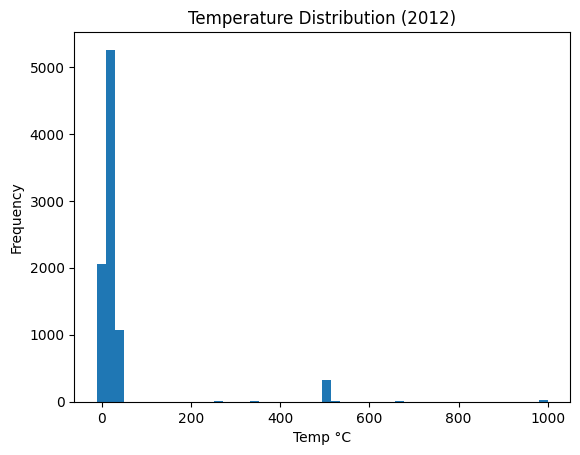

In [ ]:
import matplotlib.pyplot as plt

plt.hist(hourly_stats["mean"], bins=50)
plt.title("Temperature Distribution (2012)")
plt.xlabel("Temp °C")
plt.ylabel("Frequency")
plt.show()

## Dataset 2: METAR Airport Weather Observations

### Objective

Our second weather dataset will come from **METAR aviation weather observations**.

METAR reports are standardized hourly weather observations produced by airports
around the world. These reports include information such as:

- temperature
- dew point
- wind speed and direction
- visibility
- precipitation
- atmospheric pressure
- cloud coverage

For this project we will retrieve METAR observations from:

**Station:** KOKC  
**Location:** Will Rogers World Airport (Oklahoma City)

### Why Are We Collecting This Data?

This dataset will allow us to compare multiple independent weather sources.

Our project goal is to study **agreement between weather data sources**, which means
we want to measure how often different systems report similar or conflicting weather
conditions.

We currently have:

| Source | Type |
|------|------|
NOAA ISD | historical weather archive |
METAR | airport observations |
Forecast API | predicted weather |

METAR will serve as an **independent observational dataset** that we can later compare
against the NOAA dataset and forecast models.

### Output

The dataset will be saved to:


data/raw/metar_okc_2012.csv


We are intentionally storing raw data without modification so that the original
source data is preserved.


### Plan for Retrieving METAR Data

To retrieve the METAR dataset we will use a publicly available data service
provided by the **Iowa Environmental Mesonet (IEM)**.

This service allows us to download historical METAR observations as CSV files.

The process will involve the following steps:

1. Define the weather station we want to analyze
2. Define the date range of interest (2012)
3. Construct a request to the Mesonet data service
4. Send the request using Python's `requests` library
5. Save the returned CSV data to our raw data directory
6. Verify that the dataset downloaded correctly

Each of these steps will be implemented carefully so that the notebook
remains readable and reproducible.

### Step 1: Define Request Parameters

Before we download the METAR dataset we must define the parameters of the request.

The important parameters include:

- **Station ID** — KOKC (Oklahoma City airport)
- **Date Range** — January 1, 2012 through December 31, 2012
- **Output Format** — CSV
- **Timezone** — UTC

We will also define the location where the dataset will be stored so that
our project maintains a consistent directory structure.

In [ ]:
from pathlib import Path

# ----------------------------------------
# Define project paths
# ----------------------------------------

raw_data_directory = Path("data/raw")

# ----------------------------------------
# Define METAR dataset parameters
# ----------------------------------------

metar_station_identifier = "KOKC"

metar_start_year = 2012
metar_start_month = 1
metar_start_day = 1

metar_end_year = 2012
metar_end_month = 12
metar_end_day = 31

# ----------------------------------------
# Define output file location
# ----------------------------------------

metar_output_file = raw_data_directory / "metar_okc_2012.csv"

print("Station:", metar_station_identifier)
print("Date range:", f"{metar_start_year}-01-01 through {metar_end_year}-12-31")
print("Output file:", metar_output_file)

Station: KOKC
Date range: 2012-01-01 through 2012-12-31
Output file: data\raw\metar_okc_2012.csv


### Explanation of the Parameter Setup

In the previous step we defined all parameters required for the METAR request.

Several design choices were intentional:

**Readable variable names**

Instead of short names like `s` or `yr`, we use descriptive variable names
such as `metar_station_identifier` and `metar_start_year`. This improves
readability for students and collaborators.

**Explicit date components**

Breaking the date into year/month/day components makes the request parameters
clear and easy to modify later if we wish to analyze additional years.

**Centralized output path**

All raw datasets are stored inside:


data/raw/


Maintaining a strict directory structure ensures that later notebooks
(`02_clean_and_align.ipynb`) can reliably locate input datasets.


### Step 1: Define Request Parameters

Before we download the METAR dataset we must define the parameters of the request.

The important parameters include:

- **Station ID** — KOKC (Oklahoma City airport)
- **Date Range** — January 1, 2012 through December 31, 2012
- **Output Format** — CSV
- **Timezone** — UTC

We will also define the location where the dataset will be stored so that
our project maintains a consistent directory structure.

In [ ]:
from pathlib import Path

# ----------------------------------------
# Define project paths
# ----------------------------------------

raw_data_directory = Path("data/raw")

# ----------------------------------------
# Define METAR dataset parameters
# ----------------------------------------

metar_station_identifier = "KOKC"

metar_start_year = 2012
metar_start_month = 1
metar_start_day = 1

metar_end_year = 2012
metar_end_month = 12
metar_end_day = 31

# ----------------------------------------
# Define output file location
# ----------------------------------------

metar_output_file = raw_data_directory / "metar_okc_2012.csv"

print("Station:", metar_station_identifier)
print("Date range:", f"{metar_start_year}-01-01 through {metar_end_year}-12-31")
print("Output file:", metar_output_file)

Station: KOKC
Date range: 2012-01-01 through 2012-12-31
Output file: data\raw\metar_okc_2012.csv


### Explanation of the Parameter Setup

In the previous step we defined all parameters required for the METAR request.

Several design choices were intentional:

**Readable variable names**

Instead of short names like `s` or `yr`, we use descriptive variable names
such as `metar_station_identifier` and `metar_start_year`. This improves
readability for students and collaborators.

**Explicit date components**

Breaking the date into year/month/day components makes the request parameters
clear and easy to modify later if we wish to analyze additional years.

**Centralized output path**

All raw datasets are stored inside:


data/raw/


Maintaining a strict directory structure ensures that later notebooks
(`02_clean_and_align.ipynb`) can reliably locate input datasets.


### Step 2: Construct the METAR Data Request

Now that the parameters are defined we will construct the request
that will be sent to the Mesonet METAR archive service.

This request will include:

- station identifier
- date range
- desired output format
- additional metadata such as latitude, longitude, and elevation

Once the request is constructed we will send it to the server
and retrieve the dataset.

In [ ]:
import requests

mesonet_request_url = "https://mesonet.agron.iastate.edu/cgi-bin/request/asos.py"

metar_request_parameters = {

    "station": metar_station_identifier,

    "data": "all",

    "year1": metar_start_year,
    "month1": metar_start_month,
    "day1": metar_start_day,

    "year2": metar_end_year,
    "month2": metar_end_month,
    "day2": metar_end_day,

    "tz": "UTC",
    "format": "onlycomma",

    "latlon": "yes",
    "elev": "yes",

    "missing": "M",
    "trace": "T",

    "direct": "yes",

    "report_type": "1",
    "report_type": "2"
}

print("METAR request parameters constructed successfully.")

METAR request parameters constructed successfully.


### Understanding the METAR Request

The parameters provided to the Mesonet service control exactly what
data will be returned.

Important options include:

**station**

The airport weather station identifier.

Example:


KOKC


**format = onlycomma**

Requests a clean comma-separated file so the data can easily be
loaded into pandas.

**latlon = yes**

Includes geographic coordinates for the station.

**elev = yes**

Includes station elevation which may be useful for analysis.

The remaining parameters ensure that the service returns a
complete dataset without filtering out any weather observations.



In [ ]:
metar_response = requests.get(
    mesonet_request_url,
    params=metar_request_parameters
)

print("Server response code:", metar_response.status_code)

if metar_response.status_code == 200:

    with open(metar_output_file, "w", encoding="utf-8") as file_handle:
        file_handle.write(metar_response.text)

    print("METAR dataset successfully saved.")

else:
    print("Download failed.")

Server response code: 200
METAR dataset successfully saved.


### Step 3: Verify the Downloaded Dataset

After retrieving the METAR dataset we should verify that the file
was downloaded correctly and contains usable data.

We will load the dataset into pandas and inspect:

- number of rows
- number of columns
- sample records

This step ensures that our data pipeline is functioning properly
before we move on to the next data source.

In [ ]:
import pandas as pd

metar_dataframe = pd.read_csv(metar_output_file)

print("Dataset shape:", metar_dataframe.shape)

metar_dataframe.head()

Dataset shape: (9890, 33)


,station,valid,lon,lat,elevation,tmpf,dwpf,relh,drct,sknt,...,wxcodes,ice_accretion_1hr,ice_accretion_3hr,ice_accretion_6hr,peak_wind_gust,peak_wind_drct,peak_wind_time,feel,metar,snowdepth
0,OKC,2012-01-01 00:52,-97.6006,35.3889,397.0,59.00,25.00,26.90,330.00,21.00,...,M,M,M,M,29.00,330.00,2012-01-01 00:18,59.00,KOKC 010052Z 33021G27KT 10SM FEW250 15/M04 A29...,M
1,OKC,2012-01-01 01:52,-97.6006,35.3889,397.0,56.00,20.00,24.29,320.00,18.00,...,M,M,M,M,28.00,330.00,2012-01-01 01:47,55.94,KOKC 010152Z 32018G28KT 10SM FEW250 13/M07 A30...,M
2,OKC,2012-01-01 02:52,-97.6006,35.3889,397.0,52.00,28.00,39.40,310.00,28.00,...,M,M,M,M,38.00,310.00,2012-01-01 02:50,51.98,KOKC 010252Z 31028G38KT 8SM CLR 11/M02 A3008 R...,M
3,OKC,2012-01-01 03:52,-97.6006,35.3889,397.0,47.00,31.00,53.47,330.00,32.00,...,M,M,M,M,50.00,340.00,2012-01-01 03:44,36.96,KOKC 010352Z 33032G50KT 8SM CLR 08/M01 A3013 R...,M
4,OKC,2012-01-01 04:52,-97.6006,35.3889,397.0,45.00,31.00,57.63,330.00,24.00,...,M,M,M,M,43.00,330.00,2012-01-01 03:55,35.54,KOKC 010452Z 33024G33KT 10SM CLR 07/M01 A3019 ...,M
